In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
clean_df = pd.read_csv('credit_risk_cleaned.csv')

In [4]:
clean_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
model_df = clean_df[[
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status'
]]

In [6]:
X = model_df.drop(
    'loan_status',
    axis=1
)

y = model_df['loan_status']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
X_train.shape

(26059, 7)

In [10]:
X_test.shape

(6515, 7)

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [13]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [14]:
y_pred_rf = rf_model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
accuracy_score(
    y_test,
    y_pred_rf
)

0.8804297774366846

In [17]:
from sklearn.metrics import classification_report

In [18]:
report = classification_report(
    y_test,
    y_pred_rf
)

print(report)

              precision    recall  f1-score   support

           0       0.90      0.95      0.93      5099
           1       0.78      0.63      0.70      1416

    accuracy                           0.88      6515
   macro avg       0.84      0.79      0.81      6515
weighted avg       0.88      0.88      0.88      6515



# Random Forest Classification Report Insight

The Random Forest model achieved an overall accuracy of 88%, indicating strong predictive performance on the test dataset.

For non-default borrowers (Class 0), the model performed very well with a precision of 90%, recall of 95%, and F1-score of 93%. This indicates that the model was highly effective at identifying borrowers who are unlikely to default.

For default borrowers (Class 1), the model achieved a precision of 78%, recall of 63%, and F1-score of 70%. While the model successfully identified many default cases, approximately 37% of actual defaults were missed.

Overall, the model demonstrated strong performance in predicting non-default loans and reasonable effectiveness in identifying default risk, making it a useful baseline model for credit risk analysis.

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm

array([[4848,  251],
       [ 528,  888]])

In [22]:
import matplotlib.pyplot as plt

In [23]:
import seaborn as sns

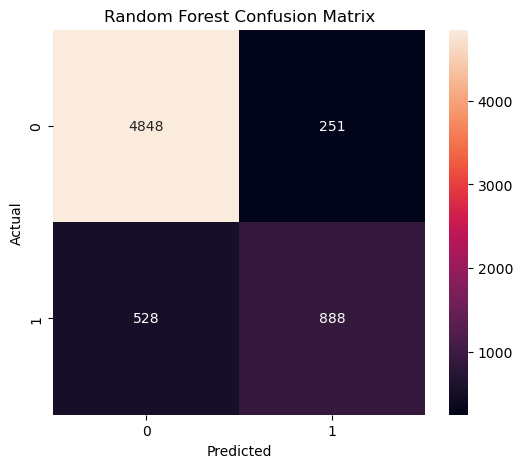

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.savefig(
    'rf_confusion_matrix.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [29]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_})

In [30]:
importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

importance_df

,feature,importance
5,loan_percent_income,0.234486
4,loan_int_rate,0.234464
1,person_income,0.208899
3,loan_amnt,0.111144
2,person_emp_length,0.077627
0,person_age,0.073667
6,cb_person_cred_hist_length,0.059713


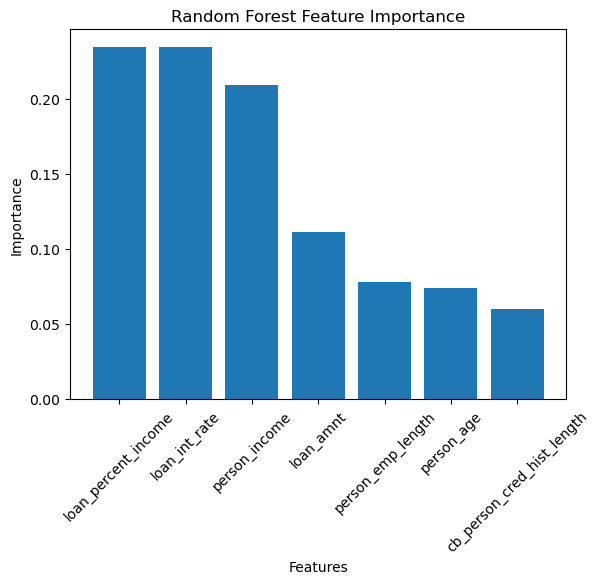

In [34]:
plt.bar(
    importance_df['feature'],
    importance_df['importance']
)

plt.xticks(rotation=45)

plt.title(
    'Random Forest Feature Importance')

plt.xlabel(
    'Features'
)

plt.ylabel(
    'Importance'
)

plt.savefig(
    'rf_feature_importance.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

# Feature Importance Insight

The Random Forest model identified loan_percent_income and loan_int_rate as the most influential variables for predicting loan default risk, each contributing approximately 23% of the model's decision-making process.

Person_income was also an important predictor, accounting for about 21% of the total importance. This suggests that a borrower's repayment burden, interest rate, and income level are the strongest indicators of default risk.

In contrast, person_age and credit history length had relatively lower importance scores, indicating that financial factors have a greater impact on loan default prediction than demographic characteristics in this dataset.

These findings suggest that lenders should pay close attention to debt burden relative to income and loan pricing when assessing borrower risk.

# Feature Importance Insight

The feature importance analysis shows that loan_percent_income and loan_int_rate are the strongest predictors of loan default, both with importance scores above 23%.

This indicates that borrowers with a higher loan burden relative to their income and higher interest rates are more likely to default. Person_income is the third most important variable, highlighting the critical role of repayment capacity in credit risk assessment.

Loan amount contributes moderately to the prediction, while age, employment length, and credit history length have comparatively smaller effects on model decisions.

Overall, the results suggest that financial capacity and borrowing burden are more influential than demographic characteristics when evaluating default risk.